1. Download the images bunny.png and cat.png. Place them in the files folder. Iterate through the two images and the time steps  0,250,500,750,  and  1,000 . Use the function linear_noisy_ image() to generate  10  images. Plot the  10  images in a  2×5  grid.

In [24]:
import torch

# assuming 1000 time steps
T=1000
# relative timesteps [0/1000, 1/1000,...,1000/1000]
t=torch.arange(0, T + 1,dtype=torch.float32)/T
def linear_scheduler():
    # values of beta1 and beta2
    beta1, beta2 = 0.0001, 0.02
    # beta_t increases linearly with time step t
    beta_t = (beta2 - beta1) * t  + beta1
    alpha_t = 1 - beta_t
    log_alpha_t = torch.log(alpha_t)
    # define alphabar_t
    alphabar_t = torch.cumsum(log_alpha_t, dim=0).exp()
    # the weight placed on the clean image x0
    sqrtab = torch.sqrt(alphabar_t)
    # the weight placed on noise 𝛆0
    sqrtmab = torch.sqrt(1 - alphabar_t)
    return {"sqrtab": sqrtab,"sqrtmab": sqrtmab}

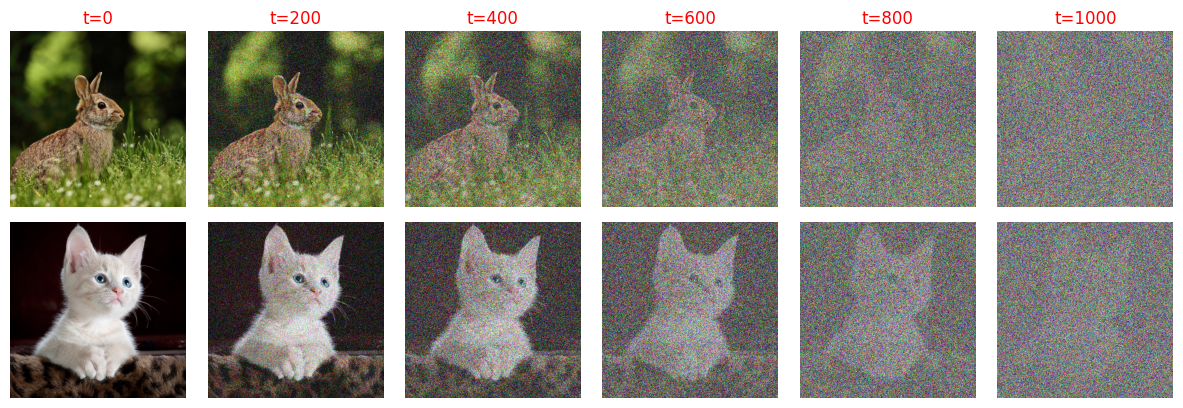

In [25]:
import matplotlib.pyplot as plt
import PIL
import numpy as np
def linear_noisy_image(image,timestep):    #Defines a function to generate noisy images from clean images with a linear diffusion schedule
    alphabar_t=linear_scheduler()["sqrtab"][timestep]
    noisy=image*torch.sqrt(alphabar_t)+\
        torch.randn_like(image)*torch.sqrt(1 - alphabar_t)
    return torch.clip(noisy,min=-1,max=1)
imgs=[]
for name in ["bunny","cat"]:
    img=np.array(PIL.Image.open(f"files/{name}.png"))
    img=torch.tensor(2*(img/255)-1)
    for timestep in [0,200,400,600,800,1000]:    #Generates noisy images at time steps 0, 200, 400, . . ., 1,000
        imgs.append(linear_noisy_image(img,timestep)/2+0.5)
plt.figure(figsize=(12,8),dpi=100)

'''
În prima parte, treci prin 2 imagini ("bunny", "cat").
Pentru fiecare imagine, o treci prin 6 pași de timp ([0, 200, 400, 600, 800, 1000]).
Deci, în lista ta imgs se salvează în total 12 imagini (2 * 6 = 12).
'''

for i in range(12):#aici-------------------------------------------------------------------ATENTIE nu este 24
    plt.subplot(4,6,i+1)    #Plots the noisy images in four rows and six columns
    plt.imshow(imgs[i])
    if i<6:
        plt.title(f't={200*(i%6)}',fontsize=12,c="r")
    plt.axis("off")
plt.tight_layout()
plt.show()

2. Download the image cat.png, and place it under the files folder. Gradually add noise to the image, and save the images in time steps  0,199,399,599,799,  and  999  under the linear diffusion schedule first and then the cosine diffusion schedule. Plot the images in a  2×6  grid.

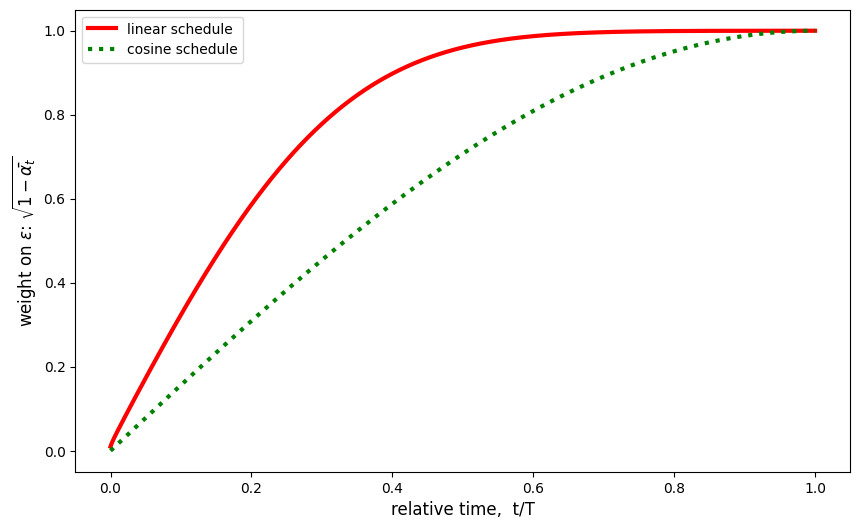

In [26]:
import math
def cosine_scheduler():    #Defines the cosine diffusion scheduler
    sqrtab = torch.cos(0.5*math.pi*t)
    sqrtmab = torch.sin(0.5*math.pi*t)
    return {"sqrtab": sqrtab,"sqrtmab": sqrtmab}

plt.figure(figsize=(10,6),dpi=100)
plt.plot(t, linear_scheduler()["sqrtmab"], linewidth=3,    #Plots the weight on the noise over time under the linear scheduler
         linestyle="solid",c="r", label="linear schedule")
plt.plot(t, cosine_scheduler()["sqrtmab"], linewidth=3,    #Plots the weight on the noise over time under the cosine scheduler
         linestyle="dotted",c="g", label="cosine schedule")
plt.xlabel(r"relative time,  t/T", fontsize=12)
plt.ylabel(r"weight on $\epsilon$: $\sqrt{1-\bar{\alpha_t}}$",
           fontsize=12)
plt.legend()
plt.show()

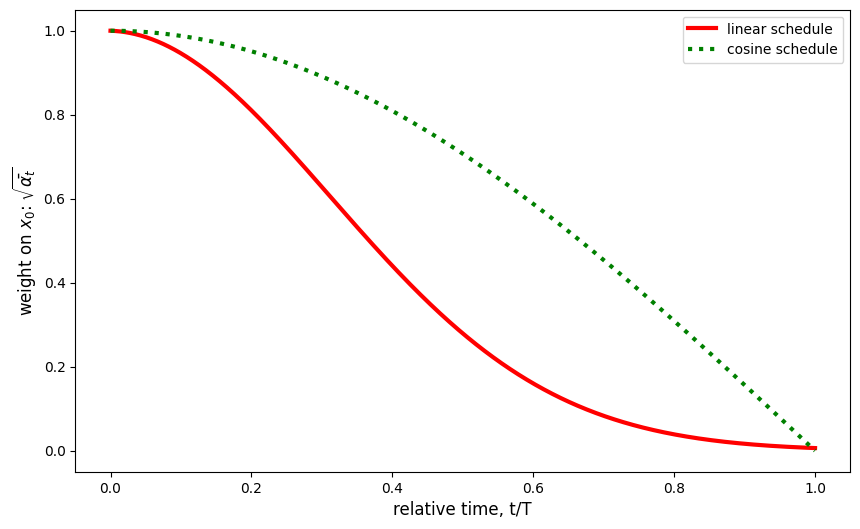

In [27]:
plt.figure(figsize=(10,6),dpi=100)
plt.plot(t, linear_scheduler()["sqrtab"], linewidth=3,    #Plots the weight on the clean image over time under the linear scheduler
         linestyle="solid",c="r", label="linear schedule")
plt.plot(t, cosine_scheduler()["sqrtab"], linewidth=3,    #Plots the weight on the clean image over time under the cosine scheduler
         linestyle="dotted",c="g", label="cosine schedule")
plt.xlabel(r"relative time, t/T", fontsize=12)
plt.ylabel(r"weight on $x_0$: $\sqrt{\bar{\alpha_t}}$",
           fontsize=12)
plt.legend()
plt.show()

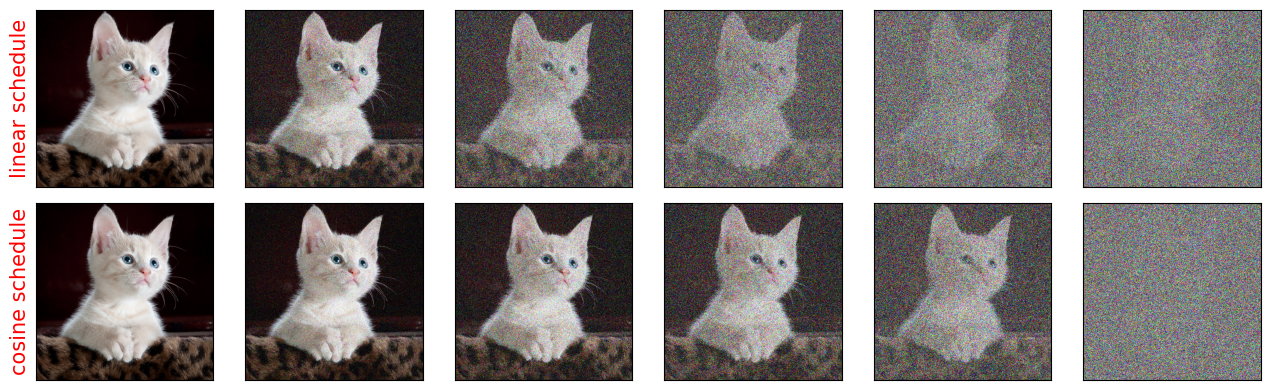

In [28]:
def cosine_noisy_image(image,timestep):    #Defines a function to generate noisy images using the cosine diffusion schedule
    alphabar_t=cosine_scheduler()["sqrtab"][timestep]
    noisy=image*torch.sqrt(alphabar_t)+\
        torch.randn_like(image)*torch.sqrt(1 - alphabar_t)
    return torch.clip(noisy,min=-1,max=1)

img=np.array(PIL.Image.open("files/cat.png"))#aici-------------------------------------------------------------------------------
img=torch.tensor(2*(img/255)-1)
imgs=[]

for timestep in [0,199,399,599,799,999]:    #aici-------------------------------------------------------------------------------
    imgs.append(linear_noisy_image(img,timestep)/2+0.5)
for timestep in [0,199,399,599,799,999]:    #aici-------------------------------------------------------------------------------
    imgs.append(cosine_noisy_image(img,timestep)/2+0.5)

plt.figure(figsize=(13,4),dpi=100)
for i in range(12):    #aici---------------------------------------------------------------------------------------------------
    plt.subplot(2,6,i+1)#aici------------------------------------------------------------------------------zice plot img de 2x6
    plt.imshow(imgs[i])
    plt.xticks([])
    plt.yticks([])
    if i==0:
        plt.ylabel("linear schedule",fontsize=15,c="r")
    if i==6:#aici-----------------------------------------------------------------------------------------------------------------
        plt.ylabel("cosine schedule",fontsize=15,c="r")
plt.tight_layout()
plt.show()

3. Set the PyTorch random state to  0 . Use the trained model to generate  16  images, and plot them in a  2×8  grid.

In [29]:
!pip install diffusers

In [30]:
import diffusers, torch

device="cuda" if torch.cuda.is_available() else "cpu"
model=diffusers.UNet2DModel(sample_size=32,    #Specifies the width and height of the input and output images
                    in_channels=1,
                    out_channels=1,layers_per_block=2,
    block_out_channels=(128,128,256,512),    #Defines the number of feature maps each block will output
    down_block_types=("DownBlock2D","DownBlock2D",    #Specifies the types of blocks used in the encoder in the U-Net
                      "AttnDownBlock2D","DownBlock2D",),
    up_block_types=("UpBlock2D","AttnUpBlock2D",    #Specifies the types of blocks used in the decoder in the U-Net
                "UpBlock2D","UpBlock2D",),).to(device)


In [31]:
from torchvision import transforms

torch.manual_seed(42)    #Fixes the random state so results are reproducible

tf = transforms.Compose(
    [transforms.Resize((32,32)),transforms.ToTensor(),
     transforms.Lambda(lambda x: 2*(x-0.5)),]    #Converts images to PyTorch tensors with values in the range [–1,1]
)


In [32]:
import torchvision

dataset = torchvision.datasets.FashionMNIST(
    r".",
    train=True,
    download=True,
    transform=tf,
)

In [33]:
text_labels=['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

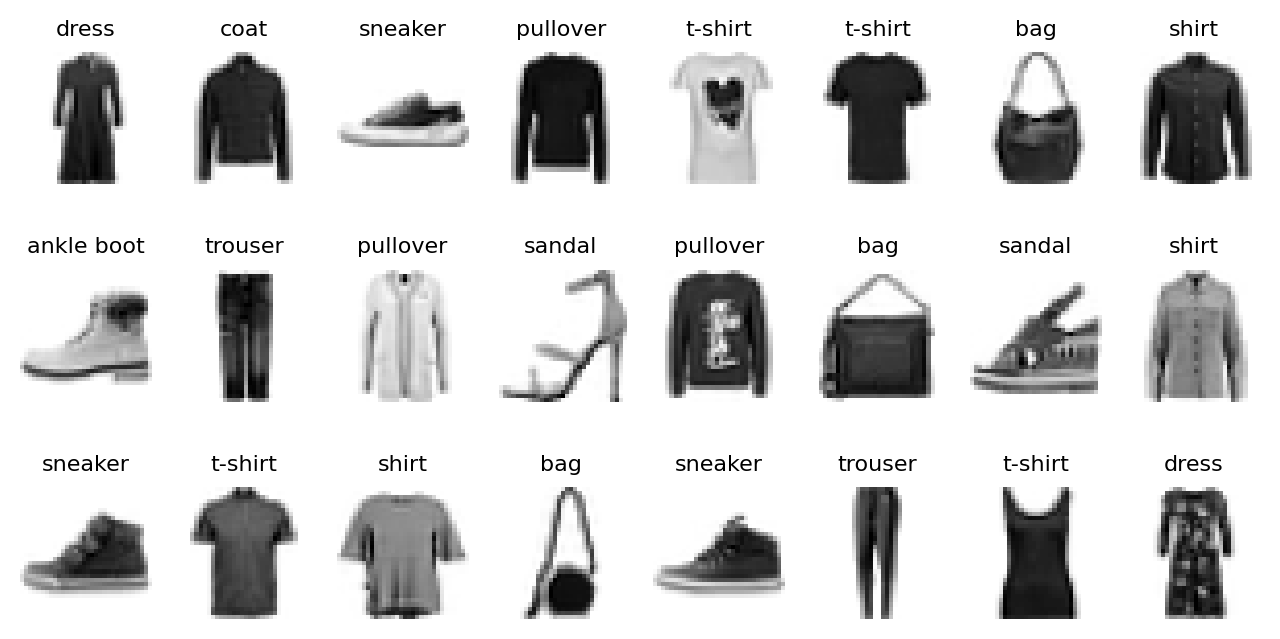

In [34]:
import matplotlib.pyplot as plt
plt.figure(dpi=200,figsize=(8,4))
for i in range(24):
    ax=plt.subplot(3, 8, i + 1)
    img=dataset[i+888][0]
    img=img/2+0.5
    img=img.reshape(32,32)
    plt.imshow(img,
    cmap="binary")
    plt.axis('off')
    plt.title(text_labels[dataset[i+888][1]],fontsize=8)
plt.show()


In [35]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

In [36]:
noise_scheduler = diffusers.DDPMScheduler(
    num_train_timesteps=1000,
  beta_schedule="squaredcos_cap_v2")

In [37]:
@torch.no_grad()
def sample(n_sample, model, noise_scheduler,seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    noise_scheduler.set_timesteps(1000)
    image=torch.randn((n_sample,1,32,32)).to(device) #Starts with pure random noise
    for t in noise_scheduler.timesteps: #Iterates over many time steps
        model_output=model(image,t)['sample'] #Predicts the noise in the image using the trained model
        image=noise_scheduler.step(model_output,int(t), #Backs out what the image looks like in the previous time step
                       image,generator=None)['prev_sample']
    return image

In [38]:
optim = torch.optim.AdamW(model.parameters(), lr=2e-4)

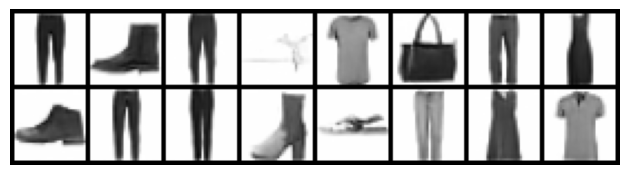

In [23]:
from tqdm import tqdm
from torchvision.utils import save_image, make_grid
torch.manual_seed(0)#aici------------------------------------------------------------------------------------------
model.load_state_dict(torch.load(
    "files/diffusion_fashion.pth",
         map_location=device,
         weights_only=True))    #Loads the trained model weights
generated_images = sample(16, model, noise_scheduler)    #aici 16 imagini-------------------------------------------
grid = make_grid(0.5-generated_images/2, nrow=8)
save_image(grid, f"files/diffusion_fashion.png")
plt.figure(dpi=100)
plt.imshow(grid.cpu().permute(1,2,0))    #Plots the images in a 4 × 8 grid
plt.axis('off')
plt.tight_layout()
plt.show()
